In [30]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, NETWORK_IDX_ENV, GCS_ADC_JSON_PATH_EP_LOCAL, BQ_DATASET_ANALYTICS, BQ_FEATURES_ENGG_TRACT
from network_idx.eda.correlations import (
    compute_all_correlations,
    get_top_correlations,
    plot_correlation_heatmap,
    correlations_with_target
)

from network_idx.utils import check_and_authenticate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# Load features table from BQ - the geometry as a dataframe
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_ANALYTICS}.{BQ_FEATURES_ENGG_TRACT}"
client = bigquery.Client(project=GCS_PROJECT_ID)
# Exclude geometry
query = f"""
    SELECT *
    FROM `{table_id}`
"""
tract_df_modified = client.query(query).to_arrow().to_pandas()
tract_df_modified.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 28 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   tract_geoid                                 83313 non-null  str    
 1   pop_ch_1yr                                  83313 non-null  float64
 2   pop_ch_avg                                  83313 non-null  float64
 3   pop_pctch_1yr                               83313 non-null  float64
 4   pop_pctch_avg                               83313 non-null  float64
 5   estimated_census_housing_units              83313 non-null  int64  
 6   estimated_fcc_units                         83313 non-null  int64  
 7   cable_max_download_speed                    80620 non-null  float64
 8   fiber_max_download_speed                    80707 non-null  float64
 9   median_dist_nearest_hotspot                 63190 non-null  float64
 10  median_dist_nearest_f

In [20]:
# Drop some columns that are not needed for correlation analysis
columns_to_drop = [
    'tract_geoid',
    'estimated_fcc_units', # highly correlated with census units
    'provider_competitive_landscape' # added ordinal variable for correlation
]
tract_df_corr = tract_df_modified.copy()
tract_df_corr = tract_df_corr.drop(columns=columns_to_drop)
tract_df_corr.info()

<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   pop_ch_1yr                                  83313 non-null  float64
 1   pop_ch_avg                                  83313 non-null  float64
 2   pop_pctch_1yr                               83313 non-null  float64
 3   pop_pctch_avg                               83313 non-null  float64
 4   estimated_census_housing_units              83313 non-null  int64  
 5   cable_max_download_speed                    80620 non-null  float64
 6   fiber_max_download_speed                    80707 non-null  float64
 7   median_dist_nearest_hotspot                 63190 non-null  float64
 8   median_dist_nearest_fiber_m                 81944 non-null  float64
 9   pre_early_dev_parcels_bin                   83313 non-null  int64  
 10  landuse_change_count_

Figure(1600x1400)


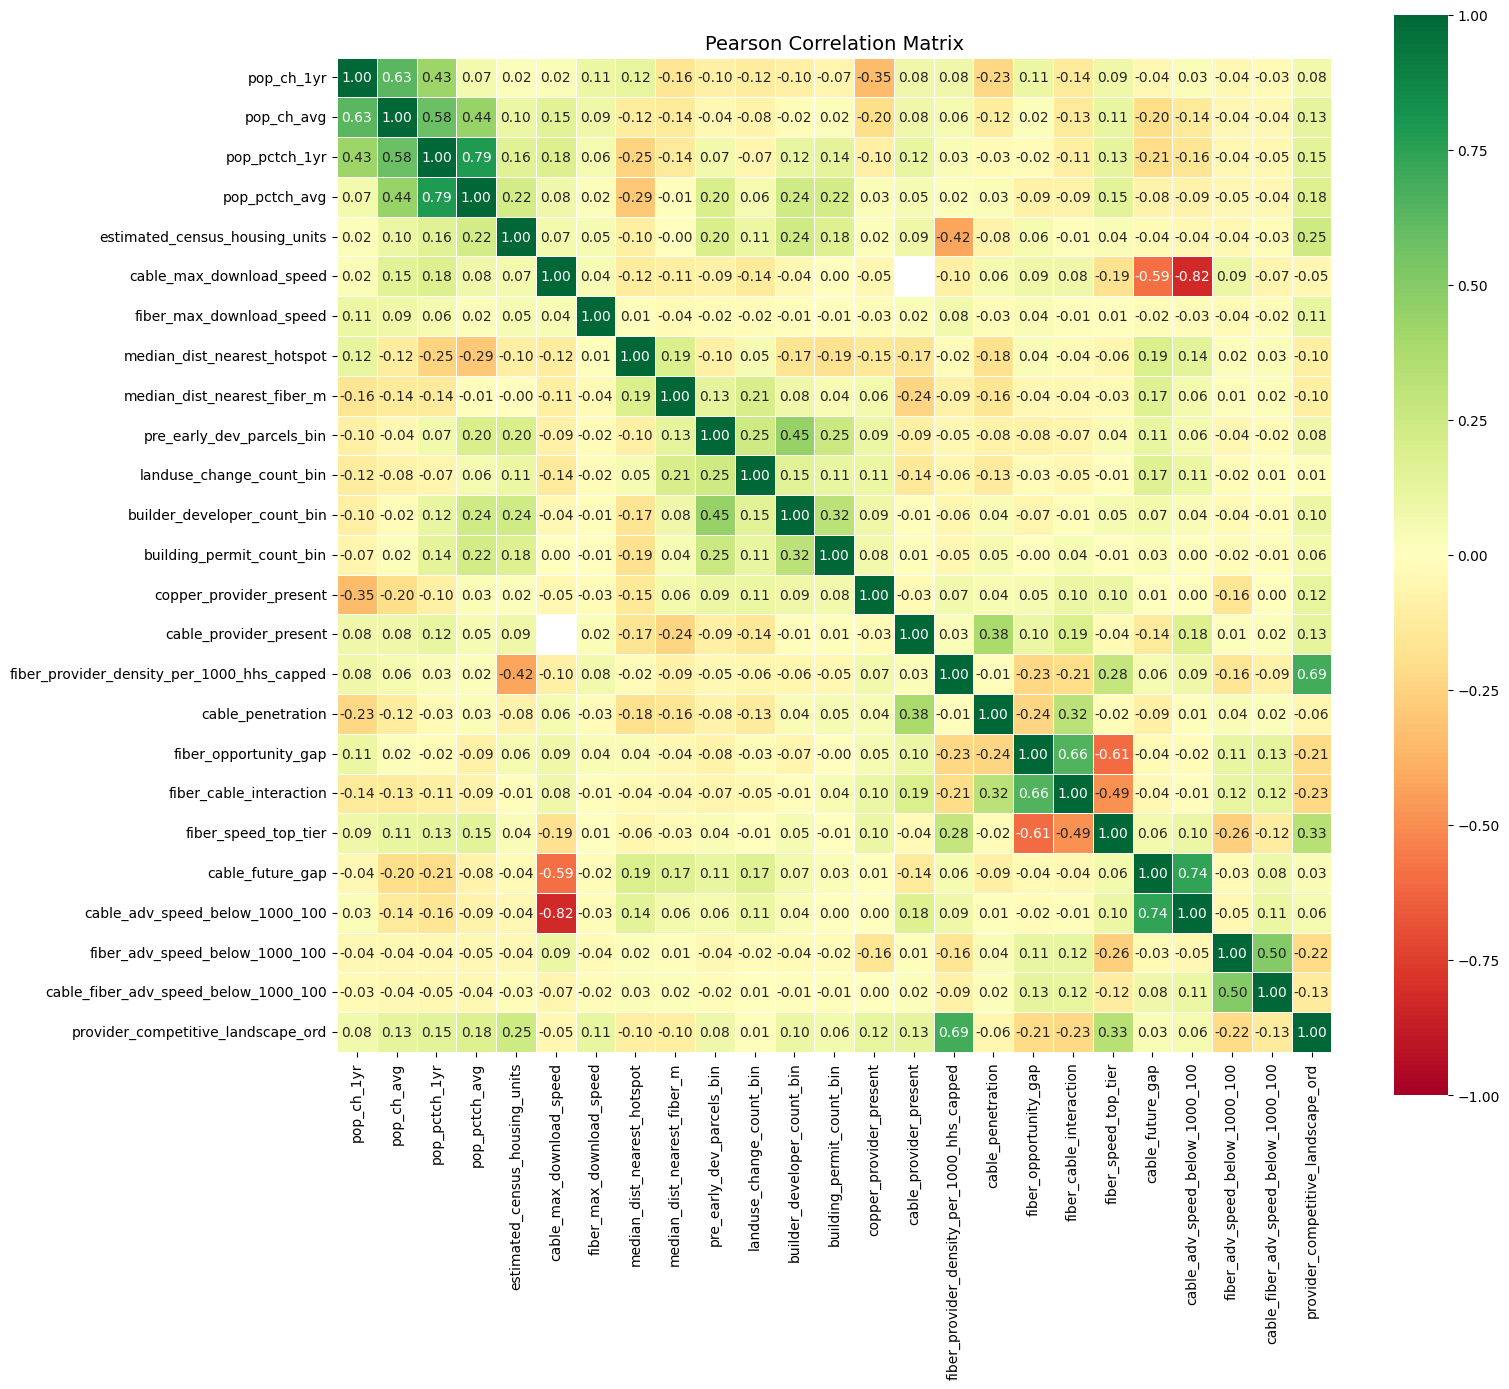

In [21]:
# Compute correlation matrix: pearson correlation that measures linear relationships between features
pearson_corr_matrix = plot_correlation_heatmap(tract_df_corr, method='pearson',cmap= "RdYlGn")
print(pearson_corr_matrix)

Figure(1600x1400)


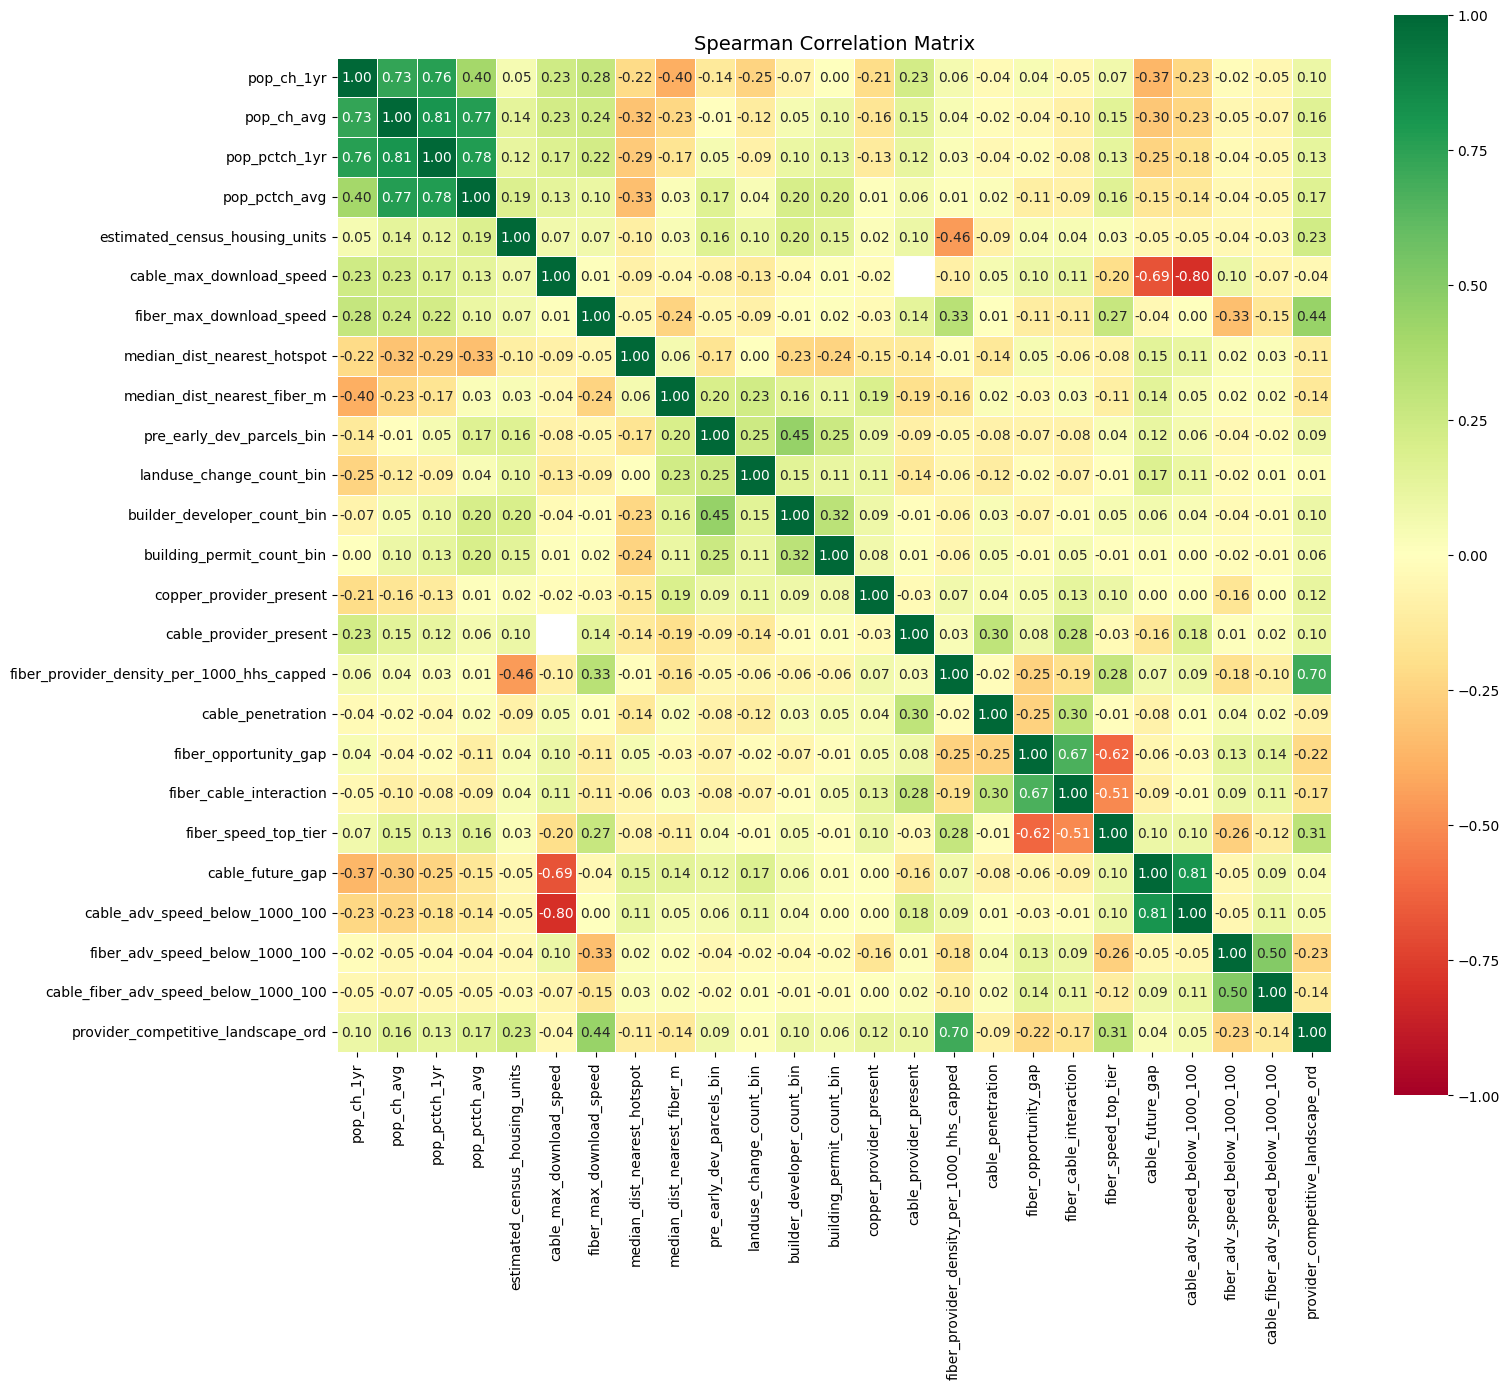

In [22]:
# Compute correlation matrix
spearman_corr_matrix = plot_correlation_heatmap(tract_df_corr, method='spearman',cmap= "RdYlGn")
print(spearman_corr_matrix)

In [24]:
# Compute top correlations: pearson
top_correlations_sp = get_top_correlations(tract_df_corr, method="spearman", n=30,min_abs_corr=0.4)
print("Top correlations with target (spearman):")
print(top_correlations_sp)

Top correlations with target (spearman):
                                     feature_1  \
0                             cable_future_gap   
1                                   pop_ch_avg   
2                     cable_max_download_speed   
3                                pop_pctch_1yr   
4                                   pop_ch_avg   
5                                   pop_ch_1yr   
6                                   pop_ch_1yr   
7   fiber_provider_density_per_1000_hhs_capped   
8                     cable_max_download_speed   
9                        fiber_opportunity_gap   
10                       fiber_opportunity_gap   
11                     fiber_cable_interaction   
12              fiber_adv_speed_below_1000_100   
13              estimated_census_housing_units   
14                   pre_early_dev_parcels_bin   
15                    fiber_max_download_speed   

                                     feature_2  correlation  
0               cable_adv_speed_below_1000_100

In [25]:
# Remove the new population change metrics for clustering
columns_to_drop = [
    # 'tract_geoid', # this is needed for clustering analysis
    'pop_ch_avg',
    'pop_pctch_avg',
    'cable_max_download_speed',
    'fiber_max_download_speed',
    'fiber_provider_density_per_1000_hhs_capped', # correlated to provider_competitive_landscape
    'cable_adv_speed_below_1000_100', # correlated to cable_future_gap
    'fiber_adv_speed_below_1000_100', # less reliable than fiber_speed_top_tier
    'fiber_cable_interaction', # correlated to fiber_opportunity_score and cable penetration is high almost everywhere so interaction is mostly driven by fiber_opportunity_gap 
    
]
tract_df_clustering = tract_df_modified.copy()
tract_df_clustering = tract_df_clustering.drop(columns=columns_to_drop)
tract_df_clustering.info()

<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   tract_geoid                           83313 non-null  str    
 1   pop_ch_1yr                            83313 non-null  float64
 2   pop_pctch_1yr                         83313 non-null  float64
 3   estimated_census_housing_units        83313 non-null  int64  
 4   estimated_fcc_units                   83313 non-null  int64  
 5   median_dist_nearest_hotspot           63190 non-null  float64
 6   median_dist_nearest_fiber_m           81944 non-null  float64
 7   pre_early_dev_parcels_bin             83313 non-null  int64  
 8   landuse_change_count_bin              83313 non-null  int64  
 9   builder_developer_count_bin           83313 non-null  int64  
 10  building_permit_count_bin             83313 non-null  int64  
 11  copper_provider_present   

In [31]:
# Upload this dataframe to BQ for clustering analysis in the next notebook
if NETWORK_IDX_ENV == "local":
    check_and_authenticate(GCS_ADC_JSON_PATH_EP_LOCAL)

client = bigquery.Client(project=GCS_PROJECT_ID)
table_id = f"{GCS_PROJECT_ID}.teu_analytics.post_corr_all_features_for_clustering_tract"

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

job = client.load_table_from_dataframe(tract_df_clustering, table_id, job_config=job_config)
job.result()

print(f"Uploaded {job.output_rows} rows to {table_id}")

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Uploaded 83313 rows to clgx-gis-app-dev-06e3.teu_analytics.post_corr_all_features_for_clustering_tract
